In [1]:
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

import pandas as pd

# Use double precision for numerical stability
torch.set_default_dtype(torch.float64)
device = torch.device("cpu")

# Input dimensionality and bounds
input_dim = 7
# Inputs are: X_0 start, X_0 end, X_1 start, X_1 end, X_0 count, X_1 count, X_1 steepness
#lower_bounds = torch.tensor([-50, -50, 0, 0, 0, 3, 0.1], dtype=torch.float64, device=device)
#upper_bounds = torch.tensor([0.0, 0.0, 10.0, 10.0, 100, 100, 7.0], dtype=torch.float64, device=device)
# The bounds for when X_0 end and X_1 end are the X diffs
#lower_bounds = torch.tensor([-50, 0, 0, 0, 0, 3, 0.1], dtype=torch.float64, device=device)
#upper_bounds = torch.tensor([0.0, 50.0, 10.0, 10.0, 100, 100, 7.0], dtype=torch.float64, device=device)
# Bounds where X0 End and X1 Start are removed
lower_bounds = torch.tensor([-50, 0, 0, 3, 0.1], dtype=torch.float64, device=device)
upper_bounds = torch.tensor([0.0, 10.0, 100, 100, 7.0], dtype=torch.float64, device=device)
bounds = torch.stack([lower_bounds, upper_bounds])


In [2]:
def load_manual_data(X_list, Y_tensor_or_list):
    X = torch.tensor(X_list, dtype=torch.float64, device=device)
    # Add filtration of the points based on the bounds given by lower_bounds and upper_bounds. If values of X are outside of the bounds, they are removed, together with the corresponding Y values.
   
    # Min-Max normalization of X
    X_min = X.min(dim=0).values
    X_max = X.max(dim=0).values
    X = (X - X_min) / (X_max - X_min)

    # if already a tensor with correct shape, don't unsqueeze
    if isinstance(Y_tensor_or_list, torch.Tensor):
        Y = Y_tensor_or_list.to(dtype=torch.float64, device=device)
    else:
        Y = torch.tensor(Y_tensor_or_list, dtype=torch.float64, device=device).unsqueeze(-1)
    # Log normalization of Y
    Y = Y.sign()*torch.log(abs(Y) + 1e-12)  # Adding a small constant
    # Min-Max normalization of Y
    # Y_min = Y.min()
    # Y_max = Y.max()
    # Y = (Y - Y_min) / (Y_max - Y_min)

    return X, Y


def train_gp_model(X, Y):
    model = SingleTaskGP(X, Y)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model

def suggest_next_point(model, best_f):
    EI = LogExpectedImprovement(model=model, best_f=best_f, maximize=True)
    candidate, _ = optimize_acqf(
        acq_function=EI,
        bounds=bounds,
        q=1,
        num_restarts=10,
        raw_samples=100,
    )
    return candidate.detach().cpu().numpy()[0]


In [3]:
def rewrite_X_dataframe(df):
    """
    Takes a DataFrame with columns:
    ['X_0 start', 'X_0 end', 'X_1 start', 'X_1 end', 'X_0 count', 'X_1 count', 'X_1 steepness']
    and rewrites it to:
    ['X_0 start', 'X_0 diff', 'X_1 start', 'X_1 diff', 'X_0 count', 'X_1 count', 'X_1 steepness']
    where X_0 diff = X_0 end - X_0 start, X_1 diff = X_1 end - X_1 start.
    """
    df_new = df.copy()
    df_new['X_0 diff'] = df_new['X_0 end'] - df_new['X_0 start']
    df_new['X_1 diff'] = df_new['X_1 end'] - df_new['X_1 start']
    cols = ['X_0 start', 'X_0 diff', 'X_1 start', 'X_1 diff', 'X_0 count', 'X_1 count', 'X_1 steepness']
    return df_new[cols]

In [ ]:
# Each input must be a 7-dimensional list
# Inputs are: X_0 start, X_0 end, X_1 start, X_1 end, X_0 count, X_1 count, X_1 steepness

settings_df = pd.read_csv("settings_results.csv")
#X_manual = torch.tensor(rewrite_X_dataframe(settings_df[["X_0 start", "X_0 end", "X_1 start", "X_1 end", "X_0 count", "X_1 count", "X_1 steepness"]]).values.tolist())
X_manual = torch.tensor(settings_df[["X_0 start", "X_1 end", "X_0 count", "X_1 count", "X_1 steepness"]].values.tolist())
Y_metrics = torch.tensor(settings_df[["MAP_52 - Lap0_52", "- MLL_52 + MLL_32", "Lap0_52 - Lap0_32", "Lap0_52"]].values.tolist())
#print(X_manual, Y_metrics)
if filter_points := True:
    mask = (X_manual >= lower_bounds) & (X_manual <= upper_bounds)
    mask = mask.all(dim=1)  # Ensure all dimensions are within bounds
    X_manual = X_manual[mask]
    if isinstance(Y_metrics, torch.Tensor):
        Y_metrics = Y_metrics[mask]
    else:
        Y_metrics = torch.tensor(Y_metrics, dtype=torch.float64, device=device)[mask]



#X_manual = [
#    [0.0, 0.0, 0.0, 3.0, 0, 5, 1.0],
#    [-6.0, -3.0, 55.0, 75.0, 61, 15, 5.0],
#    [-43.0, -42.0, 0.0, 5.0, 15, 98, 1.0],
#    [-79.0, -26.0, 84.0, 98.0, 55, 50, 24.0],
#    [-98.0, -85.0, 39.0, 92.0, 89, 94, 28.0],
#    [-22.0, -21.0, 32.0, 72.0, 63, 75, 19.0],
#    [-82.0, -24.0, 48.0, 70.0, 11, 62, 6.0],
#    [-52.0, -29.0, 34.0, 48.0, 29, 24, 12.0],
#    [-67.0, -17.0, 33.0, 68.0, 10, 52, 14.0],
#    [-44.0, -39.0, 27.0, 84.0, 68, 54, 26.0],
#    [-54.0, -13.0, 30.0, 40.0, 57, 44, 11.0],
#    [-55.0, -45.0, 28.0, 87.0, 53, 13, 1.0],
#    [-91.0, -31.0, 27.0, 83.0, 48, 67, 3.0],
#    [-89.0, -48.0, 11.0, 33.0, 25, 55, 2.0],
#    [-23.0, -32.0, 11.0, 96.0, 29, 31, 20.0],
#    [-66.0, -22.0, 24.0, 69.0, 91, 27, 27.0]
#]
#
## MAP_52 - Lap0_52, - MLL_52 + MLL_32, Lap0_52 - Lap0_32, Lap0_52
#Y_metrics = torch.tensor([
#    [0.0, 0.0, 0.012, -22],
#    [0.0, 222, 8, -748438.279],
#    [1.44, -10.7, 10.5, -67.7],
#    [0.0, 700, -33, -32286755.694],
#    [0.0, 619, 127, -30287818.928],
#    [0.0, 24000, 60, -8258717.075],
#    [0.0, 2185, 25, -1915220.389],
#    [0.0, 2300, 8, -967618.240],
#    [0.0, -9000, 30, -3868122.705],
#    [0.0, 42000, 70, -13506810.303],
#    [0.0, -110, 9, -834049.498],
#    [0.0, 0.0, 5, -77015.673],
#    [0.0, -230, 40, -847729.573],
#    [0.0, -4, 6, -37207.644],
#    [0.0, 180, 50, -8022259.941],
#    [0.0, -4400, 31, -5475305.767],
#
#], dtype=torch.float64, device=device)

# Step 1: scalarize
weights = torch.tensor([0.0, -1.0, -1.0, 0.0], dtype=torch.float64, device=device)
Y_scalar = (Y_metrics * weights).sum(dim=1, keepdim=True)  # shape: [N, 1]


In [25]:
X_tensor, Y_tensor = load_manual_data(X_manual, Y_scalar)
print(len(X_tensor), len(Y_tensor))
#print(Y_tensor)
model = train_gp_model(X_tensor, Y_tensor)
next_point = suggest_next_point(model, best_f=Y_tensor.max())
print(model(torch.tensor(next_point).reshape(1, -1)))

print("🔍 Suggested next input to try:")
# Inputs are: X_0 start, X_0 end, X_1 start, X_1 end, X_0 count, X_1 count, X_1 steepness
#print(f"X_0 start: {next_point[0]:.2f}, X_0 end: {next_point[1]:.2f}, "
#      f"X_1 start: {next_point[2]:.2f}, X_1 end: {next_point[3]:.2f}, "
#      f"X_0 count: {int(next_point[4])}, X_1 count: {int(next_point[5])}, "
#      f"X_1 steepness: {next_point[6]:.2f}")

# This is the version for when X_0 end and X_1 end are the X diffs
#print(f"X_0 start: {next_point[0]:.2f}, X_0 end: {next_point[0] + next_point[1]:.2f}, "
#      f"X_1 start: {next_point[2]:.2f}, X_1 end: {next_point[2] + next_point[3]:.2f}, "
#      f"X_0 count: {int(next_point[4])}, X_1 count: {int(next_point[5])}, "
#      f"X_1 steepness: {next_point[6]:.2f}")
# Version where X1 start and X0 end are removed
print(f"X_0 start: {next_point[0]:.2f}, X_1 end: {next_point[1]:.2f}, "
      f"X_0 count: {int(next_point[2])}, X_1 count: {int(next_point[3])}, "
      f"X_1 steepness: {next_point[4]:.2f}")

119 119
MultivariateNormal(loc: tensor([0.2216], grad_fn=<ViewBackward0>))
🔍 Suggested next input to try:
X_0 start: -27.70, X_1 end: 1.97, X_0 count: 63, X_1 count: 34, X_1 steepness: 4.15


/tmp/ipykernel_1702291/1308629004.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X_list, dtype=torch.float64, device=device)


In [6]:
len(Y_metrics)

119

In [7]:
Y_tensor

tensor([[-1.1332e+00],
        [-1.4230e+00],
        [ 1.1520e+00],
        [ 1.3697e-01],
        [ 9.7551e-01],
        [-1.9805e+00],
        [-0.0000e+00],
        [-9.8083e-01],
        [ 3.6497e+00],
        [-2.2926e+00],
        [ 1.2310e+00],
        [-2.0402e+00],
        [ 1.9038e+00],
        [ 2.3539e+00],
        [ 2.2926e+00],
        [ 9.6758e-01],
        [ 3.9601e-01],
        [-9.5192e-01],
        [ 2.1804e+00],
        [ 2.4191e+00],
        [ 1.3394e+00],
        [ 1.7430e+00],
        [ 4.6045e-01],
        [ 2.0557e+00],
        [ 9.2664e-01],
        [-6.0213e-01],
        [ 2.4889e+00],
        [ 1.0470e+00],
        [-1.5945e+00],
        [ 1.5995e+00],
        [-5.3541e-02],
        [ 2.0956e+00],
        [-1.6042e-01],
        [ 1.6045e+00],
        [-2.3126e+00],
        [ 1.2694e+00],
        [ 2.0479e+00],
        [ 2.5903e+00],
        [ 1.7373e+00],
        [ 2.9957e+00],
        [ 1.8202e+00],
        [ 1.7373e+00],
        [ 1.6451e+00],
        [ 1

IndexError: index 6 is out of bounds for dimension 1 with size 5

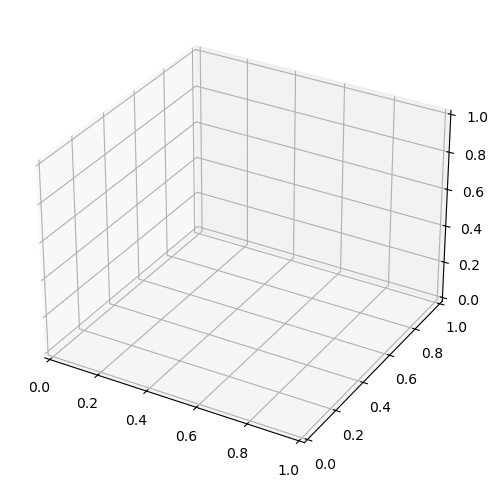

In [8]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Choose which Y output to plot against (e.g., first column of Y_metrics)
y_idx = 1  # Change this to 1, 2, or 3 for other outputs
y_label = settings_df.columns[7 + y_idx]

# Choose which three input dimensions to plot (can be changed as needed)
x_idx, y_idx2, z_idx = 0, 1, 2  # Example: first three input features
x_idx, y_idx2, z_idx = np.random.randint(0, 7, size=3)  # Example: first three input features


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: color by chosen y_label
sc = ax.scatter(
    X_tensor[:, x_idx].cpu().numpy(),
    X_tensor[:, y_idx2].cpu().numpy(),
    X_tensor[:, z_idx].cpu().numpy(),
    c=Y_metrics[:, y_idx].cpu().numpy(),
    cmap='viridis',
    alpha=0.8
)

ax.set_xlabel(f"Input {x_idx} ({settings_df.columns[x_idx]})")
ax.set_ylabel(f"Input {y_idx2} ({settings_df.columns[y_idx2]})")
ax.set_zlabel(f"Input {z_idx} ({settings_df.columns[z_idx]})")
ax.set_title(f"3D Scatter: {settings_df.columns[x_idx]}, {settings_df.columns[y_idx2]}, {settings_df.columns[z_idx]} vs {y_label}")

cb = fig.colorbar(sc, ax=ax, pad=0.1)
cb.set_label(y_label)

plt.show()